# Các Thông Số Cơ Bản Của Thống Kê Dữ Liệu Nhiều Biến

Notebook này sẽ trình bày cách tính toán các thông số thống kê cơ bản cho dữ liệu nhiều biến (multivariate data), bao gồm vector trung bình, ma trận hiệp phương sai và ma trận tương quan. Dữ liệu đầu vào là một ma trận $n \times p$, trong đó $n$ là số lượng quan sát (items) và $p$ là số lượng biến (variables).

## 1. Import Libraries

Để thực hiện các phép tính toán ma trận, chúng ta sẽ sử dụng thư viện `NumPy`.

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

## 2. Generate Sample Multivariate Data

Chúng ta sẽ tạo ngẫu nhiên một ma trận dữ liệu $n \times p$ với $n \approx 50$ quan sát và $p = 3$ biến để mô phỏng các phép tính phía sau.

In [54]:
# Load Iris dataset
iris = load_iris()

# Ma trận đầu vào n x p (n=150, p=4)
data = iris.data.astype(float)
target = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

# Nếu bạn chỉ muốn 3 biến để giữ giống notebook cũ:
# data = iris.data[:, :3].astype(float)

n, p = data.shape

print(f"Iris data matrix: {n} observations, {p} variables")
print("Feature names:", feature_names)
print("Target names:", target_names)
print(data[:5])  # xem 5 dòng đầu

Iris data matrix: 150 observations, 4 variables
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## 3. Calculate Mean Vector

Vector trung bình $\bar{\mathbf{x}} = [\bar{x}_1, \bar{x}_2, \ldots, \bar{x}_p]^T$ được tính bằng cách lấy trung bình của từng biến: $\bar{x}_j = \frac{1}{n} \sum_{i=1}^{n} x_{ij}$.

In [55]:
mean_vector = np.zeros(p, dtype=float)
for j in range(p):
    column_sum = 0.0
    for i in range(n):
        column_sum += data[i, j]
    mean_vector[j] = column_sum / n

print("Mean Vector:")
print(mean_vector)

Mean Vector:
[5.84333333 3.05733333 3.758      1.19933333]


## 4. Calculate Variance Vector

Phương sai mẫu của từng biến phản ánh mức độ phân tán riêng lẻ: $s_j^2 = \frac{1}{n} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)^2$. Ta sẽ tự triển khai công thức này thông qua các vòng lặp.

In [56]:
variance_vector = np.zeros(p, dtype=float)
for j in range(p):
    accum = 0.0
    for i in range(n):
        diff = data[i, j] - mean_vector[j]
        accum += diff * diff
    variance_vector[j] = accum / n 

print("Variance Vector (sample variance for each variable):")
print(variance_vector)

Variance Vector (sample variance for each variable):
[0.68112222 0.18871289 3.09550267 0.57713289]


## 5. Calculate Covariance Matrix

Ma trận hiệp phương sai $S$ đo lường mức độ biến thiên cùng nhau của các biến và được tính bằng: $S_{jk} = \frac{1}{n} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)$.

In [57]:
cov_matrix = np.zeros((p, p), dtype=float)
for j in range(p):
    for k in range(p):
        accum = 0.0
        for i in range(n):
            diff_j = data[i, j] - mean_vector[j]
            diff_k = data[i, k] - mean_vector[k]
            accum += diff_j * diff_k
        cov_matrix[j, k] = accum / n

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]]


## 6. Calculate Correlation Matrix

Ma trận hệ số tương quan $R$ chuẩn hóa hiệp phương sai về khoảng $[-1, 1]$: $R_{jk} = \frac{S_{jk}}{\sqrt{S_{jj} S_{kk}}}$. Ta sẽ tính toán thủ công dựa trên ma trận hiệp phương sai và vector phương sai đã có.

In [58]:
corr_matrix = np.zeros((p, p), dtype=float)
for j in range(p):
    for k in range(p):
        denom = (variance_vector[j] * variance_vector[k]) ** 0.5
        if denom == 0:
            corr_matrix[j, k] = 0.0
        else:
            corr_matrix[j, k] = cov_matrix[j, k] / denom

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]


## 7. Visualize Summary Statistics

Biểu diễn trực quan giúp nhận biết nhanh các mẫu hình giữa các biến. Ở đây ta minh họa:
- Biểu đồ cột cho vector trung bình và phương sai.
- Heatmap cho ma trận hiệp phương sai và hệ số tương quan.

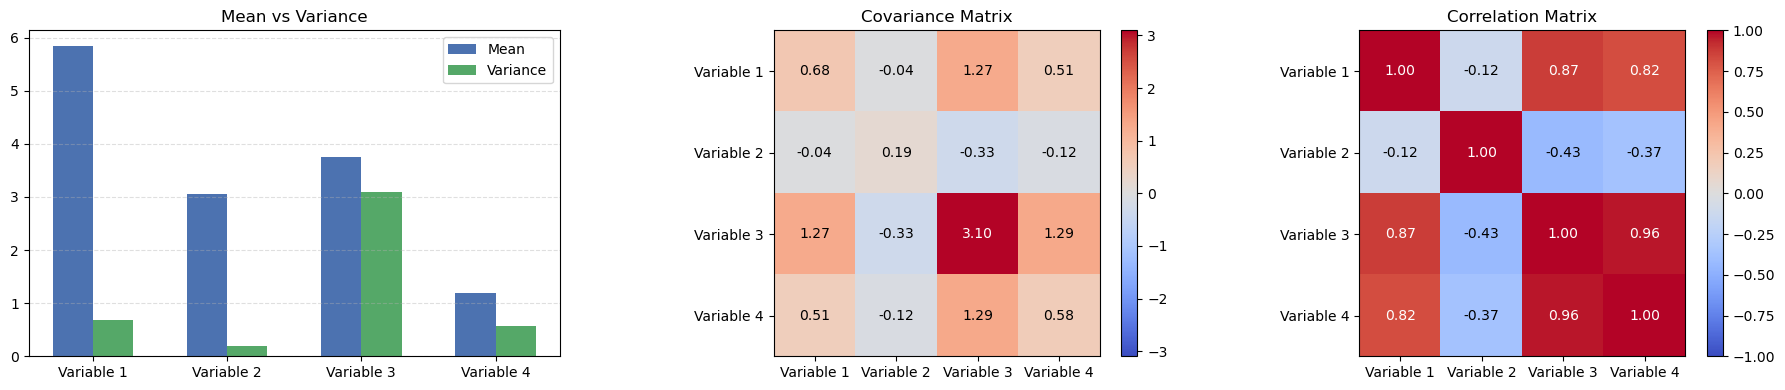

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
var_labels = [f"Variable {idx+1}" for idx in range(p)]
positions = np.arange(p)

# Bar chart to compare mean vs variance magnitude per variable
axes[0].bar(positions - 0.15, mean_vector, width=0.3, label="Mean", color="#4C72B0")
axes[0].bar(positions + 0.15, variance_vector, width=0.3, label="Variance", color="#55A868")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(var_labels)
axes[0].set_title("Mean vs Variance")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

heatmap_targets = [
    (cov_matrix, "Covariance Matrix"),
    (corr_matrix, "Correlation Matrix")
]

for ax, (matrix, title) in zip(axes[1:], heatmap_targets):
    scale = np.max(np.abs(matrix)) or 1.0
    im = ax.imshow(matrix, cmap="coolwarm", vmin=-scale, vmax=scale)
    ax.set_xticks(positions)
    ax.set_yticks(positions)
    ax.set_xticklabels(var_labels)
    ax.set_yticklabels(var_labels)
    ax.set_title(title)
    for row in range(p):
        for col in range(p):
            value = matrix[row, col]
            text_color = "white" if abs(value) > scale * 0.5 else "black"
            ax.text(col, row, f"{value:.2f}", ha="center", va="center", color=text_color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 8. Hình Học Của Các Thông Số

- Vector trung bình là tâm hình học (centroid) của đám mây điểm.
- Ma trận hiệp phương sai mô tả hình dạng ellip bao trùm dữ liệu thông qua các trị riêng.
- Ma trận tương quan giữ nguyên hướng ellip nhưng thu nhỏ theo độ dài chuẩn hóa.

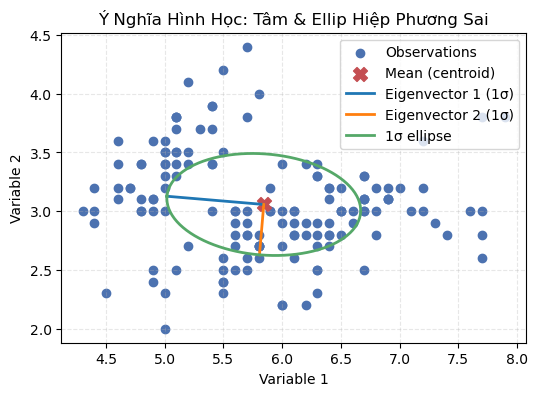

In [60]:
if p < 2:
    print("Cần ít nhất 2 biến để minh hoạ hình học trong mặt phẳng.")
else:
    mean_2d = mean_vector[:2]
    cov_2d = cov_matrix[:2, :2]
    data_2d = data[:, :2]

    def eigen_decomposition_2x2(matrix_2x2):
        a = matrix_2x2[0, 0]
        b = matrix_2x2[0, 1]
        c = matrix_2x2[1, 0]
        d = matrix_2x2[1, 1]
        trace = a + d
        determinant = a * d - b * c
        discriminant = trace * trace - 4.0 * determinant
        discriminant = discriminant if discriminant > 0 else 0.0
        sqrt_disc = discriminant ** 0.5
        lambda1 = 0.5 * (trace + sqrt_disc)
        lambda2 = 0.5 * (trace - sqrt_disc)

        def normalize(vec):
            norm = (vec[0] * vec[0] + vec[1] * vec[1]) ** 0.5
            if norm == 0:
                return np.array([1.0, 0.0], dtype=float)
            return vec / norm

        vec1 = np.array([b, lambda1 - a], dtype=float)
        if abs(vec1[0]) < 1e-10 and abs(vec1[1]) < 1e-10:
            vec1 = np.array([lambda1 - d, c], dtype=float)
        vec1 = normalize(vec1)
        vec2 = np.array([-vec1[1], vec1[0]], dtype=float)

        eigenvalues = np.array([lambda1, lambda2], dtype=float)
        eigenvectors = np.zeros((2, 2), dtype=float)
        for row in range(2):
            eigenvectors[row, 0] = vec1[row]
            eigenvectors[row, 1] = vec2[row]
        return eigenvalues, eigenvectors

    eigen_vals, eigen_vecs = eigen_decomposition_2x2(cov_2d)
    std_lengths = np.zeros(2, dtype=float)
    for idx in range(2):
        std_lengths[idx] = eigen_vals[idx] if eigen_vals[idx] > 0 else 0.0
        std_lengths[idx] = std_lengths[idx] ** 0.5

    angle_samples = np.linspace(0, 2 * np.pi, 200)
    ellipse_points = np.zeros((angle_samples.size, 2), dtype=float)
    for idx, angle in enumerate(angle_samples):
        unit_circle = np.array([np.cos(angle), np.sin(angle)], dtype=float)
        scaled = np.zeros(2, dtype=float)
        for j in range(2):
            scaled[j] = std_lengths[j] * unit_circle[j]
        transformed = np.zeros(2, dtype=float)
        for row in range(2):
            for col in range(2):
                transformed[row] += eigen_vecs[row, col] * scaled[col]
        ellipse_points[idx] = mean_2d + transformed

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(data_2d[:, 0], data_2d[:, 1], color="#4C72B0", label="Observations")
    ax.scatter(mean_2d[0], mean_2d[1], color="#C44E52", marker="X", s=100, label="Mean (centroid)")

    for idx in range(2):
        direction = np.zeros(2, dtype=float)
        for row in range(2):
            direction[row] = eigen_vecs[row, idx] * std_lengths[idx]
        ax.plot(
            [mean_2d[0], mean_2d[0] + direction[0]],
            [mean_2d[1], mean_2d[1] + direction[1]],
            linewidth=2,
            label=f"Eigenvector {idx+1} (1σ)"
        )

    ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], color="#55A868", linewidth=2, label="1σ ellipse")
    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
    ax.set_title("Ý Nghĩa Hình Học: Tâm & Ellip Hiệp Phương Sai")
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_aspect("equal", adjustable="box")
    plt.show()

## 9. Advanced Multivariate Visualizations (Iris)

Phần này minh họa thêm các kỹ thuật trực quan hóa dữ liệu nhiều biến trên Iris dataset:

- Dot diagrams + scatter plot
- Multiple scatter plot (scatter matrix)
- 3D scatter plot theo nhóm
- Growth curves
- Stars
- Chernoff faces

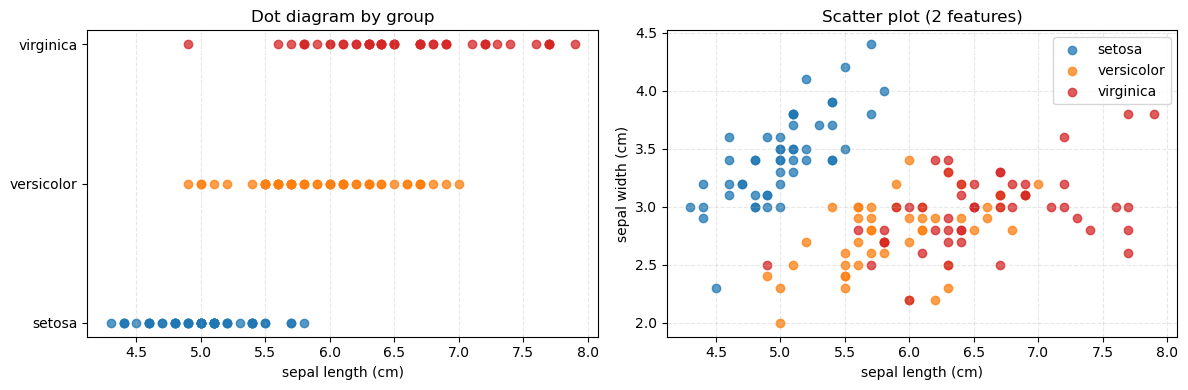

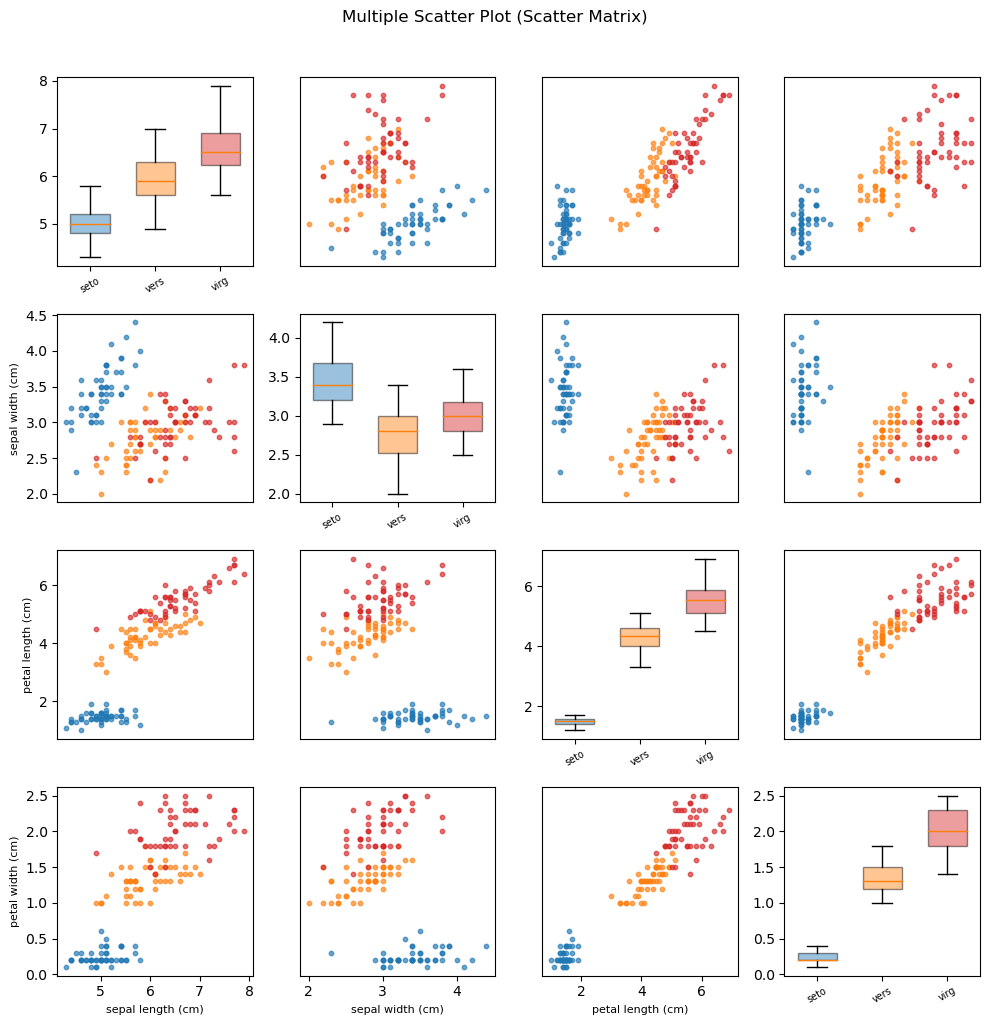

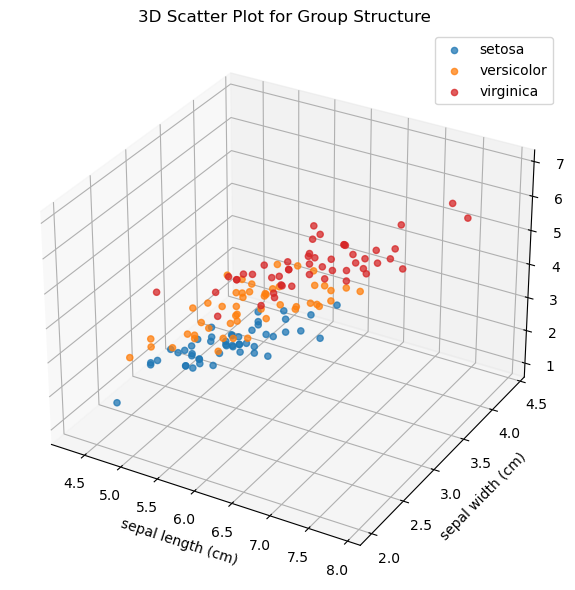

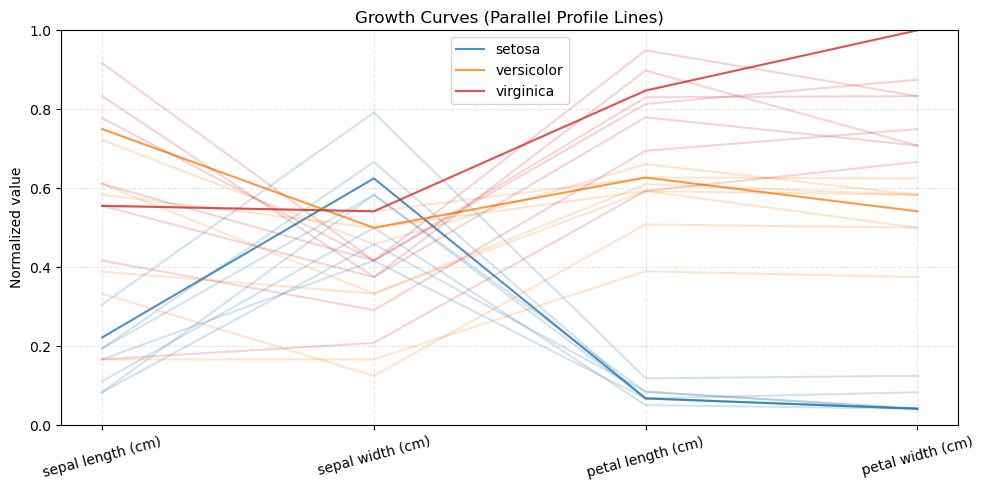

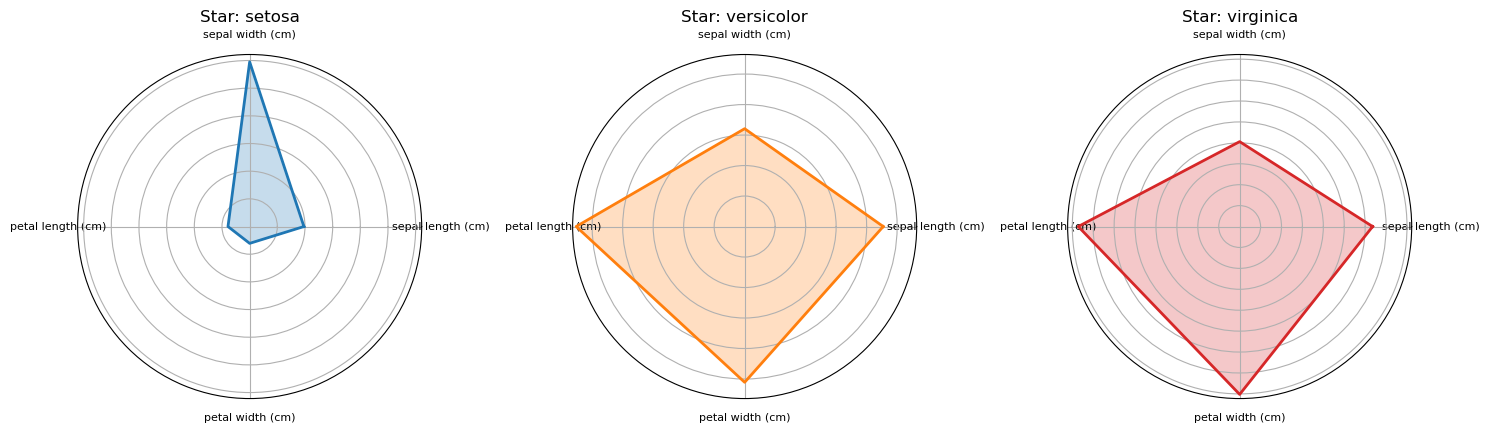

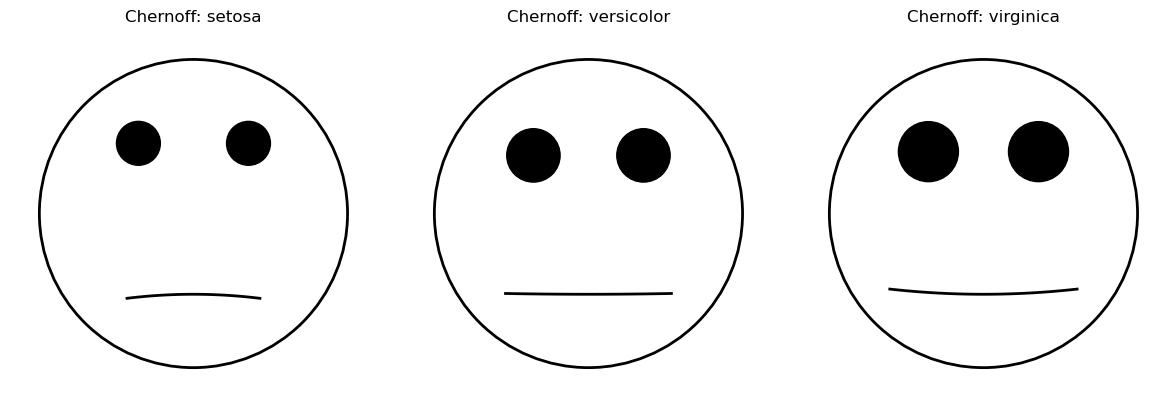

In [61]:
# Chuẩn hóa dữ liệu về [0, 1] để dùng cho nhiều biểu đồ dạng profile
mins = data.min(axis=0)
maxs = data.max(axis=0)
ranges = maxs - mins
ranges[ranges == 0] = 1.0
data_norm = (data - mins) / ranges

# setosa: xanh dương, versicolor: cam, virginica: đỏ
colors = ["#1f77b4", "#ff7f0e", "#d62728"]
labels = [target_names[i] for i in target]

# 1) Dot diagrams + Scatter plot (2 biến đầu)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for g, color in enumerate(colors):
    mask = target == g
    axes[0].scatter(data[mask, 0], np.full(mask.sum(), g), alpha=0.75, color=color, label=target_names[g])
axes[0].set_xlabel(feature_names[0])
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(target_names)
axes[0].set_title("Dot diagram by group")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)

for g, color in enumerate(colors):
    mask = target == g
    axes[1].scatter(data[mask, 0], data[mask, 1], alpha=0.75, color=color, label=target_names[g])
axes[1].set_xlabel(feature_names[0])
axes[1].set_ylabel(feature_names[1])
axes[1].set_title("Scatter plot (2 features)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Multiple scatter plot (scatter matrix thủ công, đường chéo là boxplot)
num_features = data.shape[1]
fig, axes = plt.subplots(num_features, num_features, figsize=(10, 10))
for i in range(num_features):
    for j in range(num_features):
        ax = axes[i, j]
        if i == j:
            grouped_vals = [data[target == g, j] for g in range(len(target_names))]
            bp = ax.boxplot(grouped_vals, patch_artist=True, widths=0.6, showfliers=False)
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.45)
            ax.set_xticks([1, 2, 3])
            ax.set_xticklabels([name[:4] for name in target_names], fontsize=7, rotation=30)
        else:
            for g, color in enumerate(colors):
                mask = target == g
                ax.scatter(data[mask, j], data[mask, i], s=10, alpha=0.65, color=color)
        if i == num_features - 1 and i != j:
            ax.set_xlabel(feature_names[j], fontsize=8)
        elif i != j:
            ax.set_xticks([])
        if j == 0 and i != j:
            ax.set_ylabel(feature_names[i], fontsize=8)
        elif i != j:
            ax.set_yticks([])
plt.suptitle("Multiple Scatter Plot (Scatter Matrix)", y=1.02)
plt.tight_layout()
plt.show()

# 3) 3D scatter plot (group structure)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
for g, color in enumerate(colors):
    mask = target == g
    ax.scatter(
        data[mask, 0], data[mask, 1], data[mask, 2],
        color=color, alpha=0.75, label=target_names[g]
    )
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_zlabel(feature_names[2])
ax.set_title("3D Scatter Plot for Group Structure")
ax.legend()
plt.tight_layout()
plt.show()

# 4) Graph of growth curves (parallel profiles cho một số quan sát)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(num_features)
sample_per_group = 8
for g, color in enumerate(colors):
    idx = np.where(target == g)[0][:sample_per_group]
    for k, row_idx in enumerate(idx):
        alpha = 0.2 + 0.6 * (k == 0)
        label = target_names[g] if k == 0 else None
        ax.plot(x, data_norm[row_idx], color=color, alpha=alpha, linewidth=1.5, label=label)
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=15)
ax.set_ylim(0, 1)
ax.set_ylabel("Normalized value")
ax.set_title("Growth Curves (Parallel Profile Lines)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 5) Stars (star glyphs cho trung bình từng nhóm)
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": "polar"})
for g, ax in enumerate(axes):
    mean_profile = data_norm[target == g].mean(axis=0)
    values = np.concatenate([mean_profile, [mean_profile[0]]])
    ax.plot(angles_closed, values, color=colors[g], linewidth=2)
    ax.fill(angles_closed, values, color=colors[g], alpha=0.25)
    ax.set_xticks(angles)
    ax.set_xticklabels(feature_names, fontsize=8)
    ax.set_yticklabels([])
    ax.set_title(f"Star: {target_names[g]}")
plt.tight_layout()
plt.show()

# 6) Chernoff Faces (vẽ mặt đơn giản từ 4 biến đã chuẩn hóa)
def draw_face(ax, values, title=""):
    # values gồm 4 phần tử trong [0, 1]
    eye_size = 0.05 + 0.05 * values[0]
    eye_y = 0.62 + 0.12 * values[1]
    mouth_curve = -0.4 + 0.8 * values[2]
    mouth_width = 0.35 + 0.2 * values[3]

    face = plt.Circle((0.5, 0.5), 0.42, fill=False, linewidth=2)
    ax.add_patch(face)

    left_eye = plt.Circle((0.35, eye_y), eye_size, color="black")
    right_eye = plt.Circle((0.65, eye_y), eye_size, color="black")
    ax.add_patch(left_eye)
    ax.add_patch(right_eye)

    xs = np.linspace(0.5 - mouth_width / 2, 0.5 + mouth_width / 2, 100)
    ys = 0.28 + mouth_curve * (xs - 0.5) ** 2
    ax.plot(xs, ys, color="black", linewidth=2)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

group_means = np.array([data_norm[target == g].mean(axis=0) for g in range(3)])
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for g, ax in enumerate(axes):
    draw_face(ax, group_means[g], title=f"Chernoff: {target_names[g]}")
plt.tight_layout()
plt.show()

## 10. t-SNE Visualization

t-SNE (t-distributed Stochastic Neighbor Embedding) giúp biểu diễn dữ liệu nhiều chiều về 2D để quan sát cấu trúc nhóm. Vì t-SNE nhạy với scale, ta chuẩn hóa dữ liệu trước khi giảm chiều.

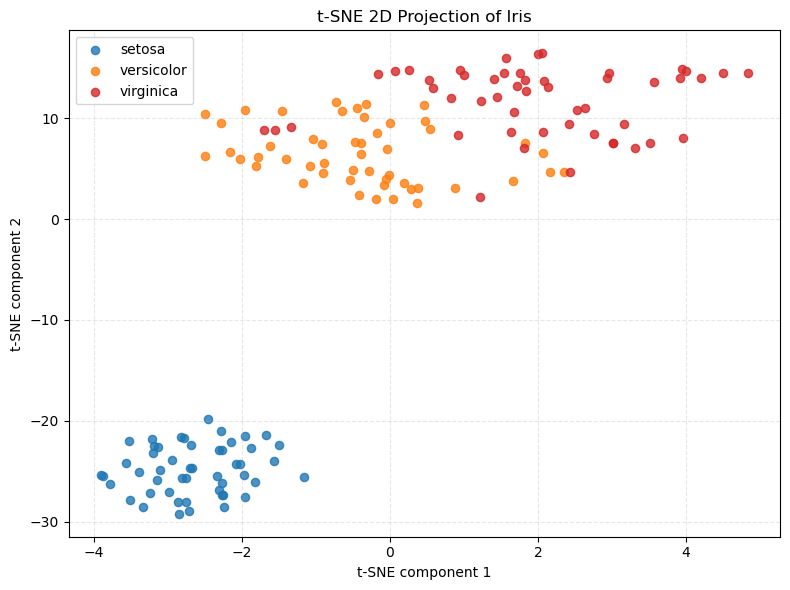

In [62]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa trước khi chạy t-SNE
X_scaled = StandardScaler().fit_transform(data)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
    )
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for g, color in enumerate(colors):
    mask = target == g
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        color=color, alpha=0.8, s=35, label=target_names[g]
    )
ax.set_title("t-SNE 2D Projection of Iris")
ax.set_xlabel("t-SNE component 1")
ax.set_ylabel("t-SNE component 2")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Statistical Distance (Khoảng cách Mahalanobis)

Khoảng cách thống kê từ một quan sát $\mathbf{x}$ đến trọng tâm $\mathbf{\bar{x}}$ của tập dữ liệu được tính bằng công thức:
$$D^2 = (\mathbf{x} - \mathbf{\bar{x}})^T S^{-1} (\mathbf{x} - \mathbf{\bar{x}})$$

Việc nhân với nghịch đảo của ma trận hiệp phương sai ($S^{-1}$) giúp tự động chuẩn hóa sự khác biệt về thang đo (scale) giữa 4 biến của hoa Iris (ví dụ chiều dài cánh hoa vs chiều rộng đài hoa) và loại bỏ sự tương quan giữa chúng.

In [63]:
def calculate_statistical_distance(x, mean_vec, cov_mat):
    """
    Calculate Mahalanobis distance for a single observation vector.
    Use pseudo-inverse (pinv) to prevent errors if the matrix is singular.
    """
    # Calculate the difference vector
    diff = x - mean_vec
    
    # Calculate the inverse of the covariance matrix
    inv_cov = np.linalg.pinv(cov_mat)
    
    # Calculate D^2 = diff^T * S^-1 * diff
    dist_squared = np.dot(np.dot(diff.T, inv_cov), diff)
    
    # Return the square root for the actual distance
    return np.sqrt(dist_squared)

print("Khoảng cách thống kê cho 5 quan sát đầu tiên trong tập dữ liệu Iris:")
print("-" * 65)
print(f"{'Chỉ số (Index)':<15} | {'Khoảng cách Euclidean':<25} | {'Khoảng cách Thống kê'}")
print("-" * 65)

# Iterate through the first 5 rows of the dataset
for i in range(5):
    obs = data[i]
    
    # Calculate standard Euclidean distance (ignores correlation)
    euclidean_dist = np.linalg.norm(obs - mean_vector)
    
    # Calculate Statistical distance (accounts for correlation and scale)
    stat_dist = calculate_statistical_distance(obs, mean_vector, cov_matrix)
    
    print(f"Quan sát {i:<6} | {euclidean_dist:<25.4f} | {stat_dist:.4f}")
print("-" * 65)

Khoảng cách thống kê cho 5 quan sát đầu tiên trong tập dữ liệu Iris:
-----------------------------------------------------------------
Chỉ số (Index)  | Khoảng cách Euclidean     | Khoảng cách Thống kê
-----------------------------------------------------------------
Quan sát 0      | 2.7032                    | 1.4659
Quan sát 1      | 2.7298                    | 1.6936
Quan sát 2      | 2.8927                    | 1.4475
Quan sát 3      | 2.7649                    | 1.5713
Quan sát 4      | 2.7504                    | 1.5744
-----------------------------------------------------------------


## 12. Large-Sample Properties: Law of Large Numbers (Luật số lớn)

Để kiểm chứng Luật số lớn trên tập Iris, chúng ta sẽ coi tập 150 bông hoa này như một "Quần thể" (Population) với các tham số thật chính là `mean_vector` và `cov_matrix` ta vừa tính. 

Ta tiến hành rút các mẫu ngẫu nhiên (có hoàn lại) từ quần thể này với kích thước $N$ tăng dần (từ 10 đến 10,000). Theo định lý, sai số giữa Trung bình/Hiệp phương sai của các mẫu này so với Quần thể sẽ tiệm cận về 0.

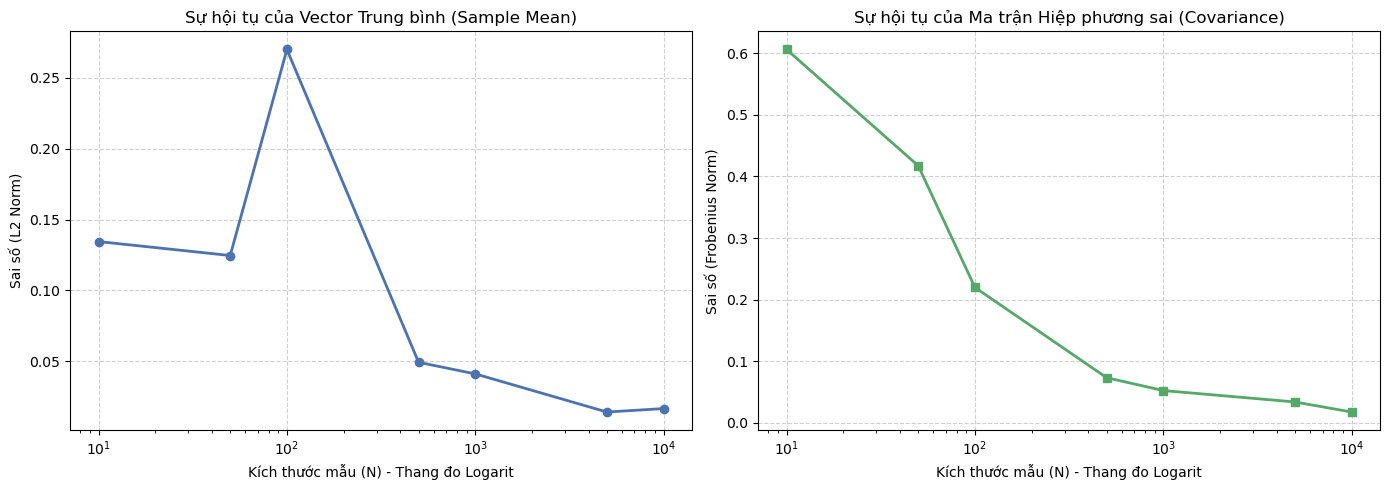

In [64]:
# Define sample sizes to simulate convergence
sample_sizes = [10, 50, 100, 500, 1000, 5000, 10000]

# Lists to store calculation errors
mean_errors = []
cov_errors = []

for size in sample_sizes:
    # Randomly draw indices with replacement from the Iris dataset
    random_indices = np.random.choice(n, size=size, replace=True)
    
    # Extract the bootstrap sample based on indices
    sample_data = data[random_indices, :]
    
    # Calculate sample statistics
    sample_mean = np.mean(sample_data, axis=0)
    # Use ddof=0 to strictly match the Maximum Likelihood Estimation (MLE) formula
    sample_cov = np.cov(sample_data, rowvar=False, ddof=0)
    
    # Calculate difference between sample statistics and true population parameters
    err_mean = np.linalg.norm(sample_mean - mean_vector)
    err_cov = np.linalg.norm(sample_cov - cov_matrix)
    
    # Store errors for visualization
    mean_errors.append(err_mean)
    cov_errors.append(err_cov)

# Create a figure with 2 side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot the convergence of the Mean Vector
ax[0].plot(sample_sizes, mean_errors, marker='o', color='#4C72B0', linewidth=2)
ax[0].set_xscale('log')
ax[0].set_xlabel('Kích thước mẫu (N) - Thang đo Logarit')
ax[0].set_ylabel('Sai số (L2 Norm)')
ax[0].set_title('Sự hội tụ của Vector Trung bình (Sample Mean)')
ax[0].grid(True, linestyle="--", alpha=0.6)

# Plot the convergence of the Covariance Matrix
ax[1].plot(sample_sizes, cov_errors, marker='s', color='#55A868', linewidth=2)
ax[1].set_xscale('log')
ax[1].set_xlabel('Kích thước mẫu (N) - Thang đo Logarit')
ax[1].set_ylabel('Sai số (Frobenius Norm)')
ax[1].set_title('Sự hội tụ của Ma trận Hiệp phương sai (Covariance)')
ax[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 13.1. Central Limit Theorem (Định lý Giới hạn Trung tâm)

Bất kể hình dáng phân phối ban đầu của 4 biến trong tập Iris có "méo mó" hay "nhiều đỉnh" (do trộn lẫn 3 loài hoa khác nhau) như thế nào, Định lý Giới hạn Trung tâm khẳng định rằng: Nếu ta rút nhiều mẫu có kích thước đủ lớn ($n_{clt} = 30$), thì phân phối của các "Vector Trung bình Mẫu" sẽ luôn có dạng hình quả chuông (Chuẩn nhiều chiều).

**Phương pháp:** Ta sẽ rút 2000 mẫu (mỗi mẫu 30 bông hoa), tính mean vector cho từng mẫu. Sau đó vẽ 4 đồ thị Histogram 1D tương ứng với 4 biến (vì không thể vẽ khối 4D) để quan sát hình dáng quả chuông.

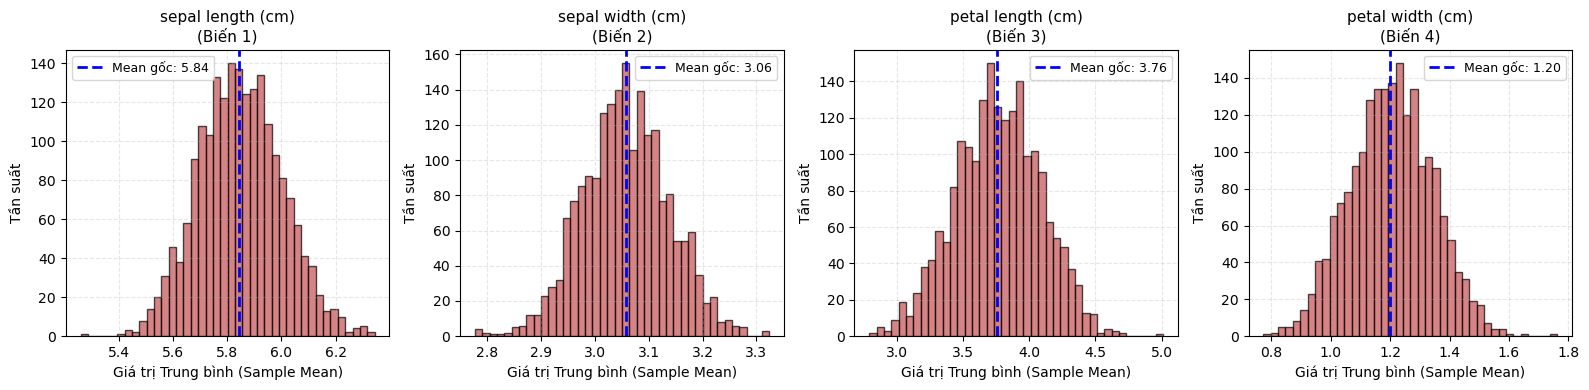

Nhận xét: Mặc dù dữ liệu Iris gốc có đặc tính phân cụm theo 3 loài hoa,
phân phối của các Sample Means ở cả 4 biến đều đối xứng hoàn hảo thành hình quả chuông (Normal Distribution)!


In [65]:
# Setup parameters for the CLT simulation
num_simulations = 2000
n_clt = 30 

# Initialize a matrix to store the mean vectors from all simulations
# Dimension will be 2000 rows by p (4) columns
bootstrap_means = np.zeros((num_simulations, p))

# Set random seed for reproducibility
np.random.seed(42)

for i in range(num_simulations):
    # Select random indices with replacement to form a bootstrap sample
    resample_idx = np.random.choice(n, size=n_clt, replace=True)
    
    # Extract the subset of data
    bootstrap_sample = data[resample_idx, :]
    
    # Calculate and store the mean vector for this specific sample
    bootstrap_means[i, :] = np.mean(bootstrap_sample, axis=0)

# Create dynamic subplots based on the number of features (p)
fig, axes = plt.subplots(1, p, figsize=(4 * p, 4))

# Handle the edge case if p == 1 to avoid indexing errors
if p == 1: 
    axes = [axes]

for j in range(p):
    # Plot a histogram for the j-th feature's sample means
    axes[j].hist(bootstrap_means[:, j], bins=40, color='#C44E52', alpha=0.7, edgecolor='black')
    
    # Draw a vertical line representing the true population mean
    axes[j].axvline(mean_vector[j], color='blue', linestyle='--', linewidth=2, 
                    label=f'Mean gốc: {mean_vector[j]:.2f}')
    
    # Set titles and labels in Vietnamese
    axes[j].set_title(f"{feature_names[j]}\n(Biến {j+1})", fontsize=11)
    axes[j].set_xlabel("Giá trị Trung bình (Sample Mean)")
    axes[j].set_ylabel("Tần suất")
    axes[j].legend(fontsize=9)
    axes[j].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print("Nhận xét: Mặc dù dữ liệu Iris gốc có đặc tính phân cụm theo 3 loài hoa,")
print("phân phối của các Sample Means ở cả 4 biến đều đối xứng hoàn hảo thành hình quả chuông (Normal Distribution)!")

## 13.2 Trực quan hóa Định lý Giới hạn Trung tâm Đa biến (2D)

Để hiểu sâu sắc hơn về tính chất hình học của phân phối chuẩn nhiều chiều, chúng ta sẽ quan sát sự phân bố của các vector trung bình mẫu trong không gian 2 chiều (2D). 

Bằng cách chọn hai biến bất kỳ (ví dụ: Sepal length và Sepal width), ta có thể vẽ biểu đồ mật độ (2D Histogram). Theo Định lý Giới hạn Trung tâm (CLT), thay vì một đường cong hình quả chuông đơn điệu, đám mây điểm của các vector trung bình này sẽ tạo thành một hình elip đặc trưng của **Phân phối Chuẩn Hai Chiều (Bivariate Normal Distribution)**. Mật độ sẽ tập trung cao nhất tại tâm quần thể và nhạt dần về các hướng theo tỷ lệ của ma trận hiệp phương sai.

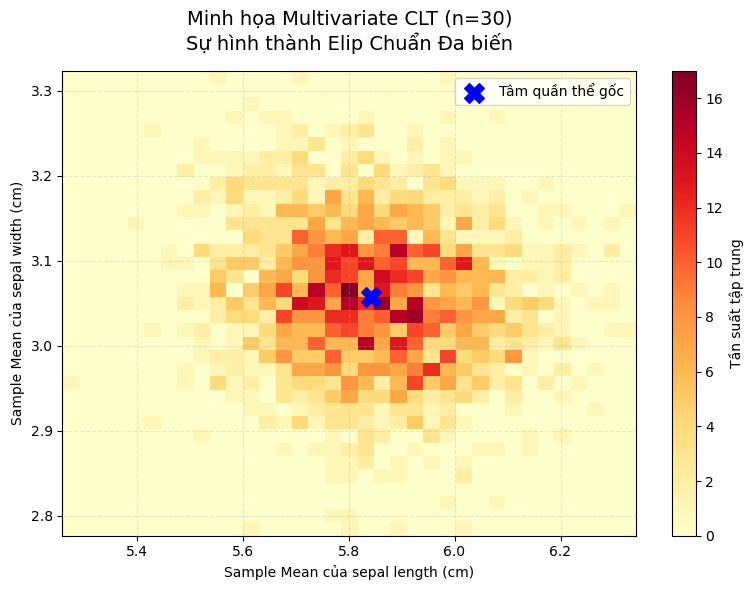

Nhận xét hình học (13.2):
- Khi kết hợp 2 biến ngẫu nhiên, ta không chỉ có hình chuông mà có một ĐÁM MÂY ĐIỂM HÌNH ELIP.
- Hình Elip này có mật độ dày đặc ở tâm (chỗ màu đỏ đậm) và nhạt dần ra xung quanh, chính là bề mặt của Phân phối Chuẩn Đa Biến (Bivariate Normal Distribution).
- Trục nghiêng của Elip thể hiện chiều hướng của Hiệp phương sai (Covariance) giữa 2 biến mẫu.


In [66]:
# Select 2 variables to observe their correlation (e.g., Sepal length and Sepal width)
var1_idx = 0
var2_idx = 1

fig, ax = plt.subplots(figsize=(8, 6))

# Plot a 2D Histogram to show the density of the Sample Mean Vectors
h = ax.hist2d(
    bootstrap_means[:, var1_idx], 
    bootstrap_means[:, var2_idx], 
    bins=35, 
    cmap='YlOrRd'  # Color scale from Yellow to Red (indicating density)
)

# Mark the True Population Mean with a large X
ax.scatter(
    mean_vector[var1_idx], 
    mean_vector[var2_idx], 
    color='blue', marker='X', s=200, label='Tâm quần thể gốc'
)

# Align and format the plot
ax.set_title(f"Minh họa Multivariate CLT (n=30)\nSự hình thành Elip Chuẩn Đa biến", fontsize=14, pad=15)
ax.set_xlabel(f"Sample Mean của {feature_names[var1_idx]}")
ax.set_ylabel(f"Sample Mean của {feature_names[var2_idx]}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

# Add a colorbar to annotate the frequency
fig.colorbar(h[3], ax=ax, label="Tần suất tập trung")

plt.tight_layout()
plt.show()

# Print concluding geometric remarks for the report
print("Nhận xét hình học (13.2):")
print("- Khi kết hợp 2 biến ngẫu nhiên, ta không chỉ có hình chuông mà có một ĐÁM MÂY ĐIỂM HÌNH ELIP.")
print("- Hình Elip này có mật độ dày đặc ở tâm (chỗ màu đỏ đậm) và nhạt dần ra xung quanh, chính là bề mặt của Phân phối Chuẩn Đa Biến (Bivariate Normal Distribution).")
print("- Trục nghiêng của Elip thể hiện chiều hướng của Hiệp phương sai (Covariance) giữa 2 biến mẫu.")